In [ ]:
import json
from pathlib import Path
from typing import Dict, Any, List, Optional

import matplotlib.pyplot as plt

In [2]:
def load_run_summary(run_dir: Path) -> Dict[str, float]:
    """
    Load accuracies from <run_dir>/summary.json.

    Returns a dict mapping group -> accuracy:
      - "overall" -> float
      - "1", "2", ... -> float (levels as strings)
    """
    run_dir = Path(run_dir).expanduser().resolve()
    summary_path = run_dir / "summary.json"
    if not summary_path.exists():
        raise FileNotFoundError(f"summary.json not found: {summary_path}")

    data: Dict[str, Any] = json.loads(summary_path.read_text(encoding="utf-8"))

    acc: Dict[str, float] = {}
    acc["overall"] = float(data.get("overall", {}).get("avg_accuracy", 0.0))

    by_level = data.get("by_level", {}) or {}
    for lvl, stats in by_level.items():
        # keys might already be strings; keep "1", "2", ...
        acc[str(lvl)] = float(stats.get("avg_accuracy", 0.0))

    return acc


def load_multiple_runs(run_dirs: List[Path]) -> Dict[str, Dict[str, float]]:
    """
    Returns:
      dict mapping run_name -> {group -> accuracy}
    where group is "overall" or a level string like "1", "2", ...
    """
    out: Dict[str, Dict[str, float]] = {}
    for rd in run_dirs:
        rd = Path(rd).expanduser().resolve()
        run_name = rd.name
        out[run_name] = load_run_summary(rd)
    return out

In [3]:
def plot_grouped_bars(
    run_acc: Dict[str, Dict[str, float]],
    title: str = "Run accuracies by level",
    out_path: Optional[Path] = None,
) -> None:
    """
    Grouped bar plot:
      x-axis groups: overall, level 1, level 2, ...
      each group: one bar per run
    """
    if not run_acc:
        print("[WARN] No runs provided.")
        return

    runs = list(run_acc.keys())

    # Collect all groups across runs
    all_groups = set()
    for acc in run_acc.values():
        all_groups.update(acc.keys())

    # Sort groups with "overall" first, then numeric levels
    def group_key(g: str):
        if g == "overall":
            return (-1, -1)
        try:
            return (0, int(g))
        except Exception:
            return (1, g)

    groups = sorted(all_groups, key=group_key)
    labels = ["overall" if g == "overall" else f"level {g}" for g in groups]

    n_groups = len(groups)
    n_runs = len(runs)

    x = list(range(n_groups))
    width = 0.8 / max(1, n_runs)

    plt.figure(figsize=(max(8, n_groups * 1.2), 4.8))

    for i, run in enumerate(runs):
        offsets = [xi - 0.4 + width / 2 + i * width for xi in x]
        heights = [run_acc[run].get(g, 0.0) for g in groups]
        plt.bar(offsets, heights, width=width, label=run)

    plt.xticks(x, labels)
    plt.ylim(0.0, 1.0)
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.tight_layout()

    if out_path:
        out_path = Path(out_path).expanduser().resolve()
        out_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(out_path, dpi=200)
        print(f"Saved plot to: {out_path}")

    plt.show()

In [6]:
run_dir = r'G:\My Drive\Gkioxari_Lab\StateWMBench\StateWM\runs'
runs = ['hunyuan_output_map_test_1', 'veo_output_map_test_1', 'wan22_output_map_test_1']
run_acc = load_multiple_runs([f"{run_dir}\\{r}" for r in runs])

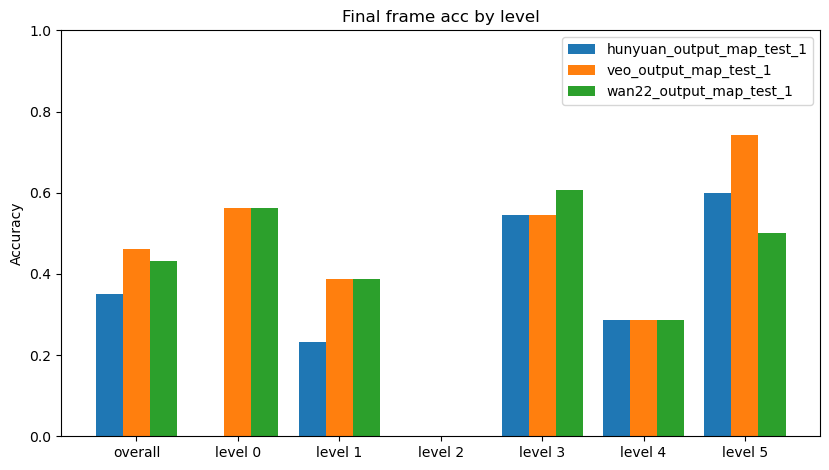

In [8]:
plot_grouped_bars(run_acc, title="Final frame acc by level")